Importation des bibliothèques

In [18]:
import os
import random
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import copy #pour copier base_model
import numpy as np
import pandas as pd
import itertools
import csv
import pickle
import matplotlib
# matplotlib.use('module://ipykernel.pylab.backend_inline')
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import ast, re

In [3]:
from models import SimpleCNN, CNN_MCdropout
from dataset import load_cifar10
from train import train_model, evaluate
from utils import mc_predict_mean_probs, generate_mc_outputs
from accuracy import accuracy_threshold, monotonic_rearrangement, isotonic_regression, monotonicity_penalty

In [4]:
print(os.getcwd())  # donne le répertoire courant

d:\INRIA\MCDropout\Monte Carlo Dropout


Fixation du seed pour la reproductibilité

In [5]:
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Configuration de base

Importation du modèle déjà entraîné par l'utilisateur

In [6]:
trainloader, valloader, testloader, classes = load_cifar10(batch_size=128, val_ratio=0.1)

100%|██████████| 170M/170M [00:56<00:00, 3.04MB/s] 


In [6]:
device = torch.device("cuda")
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0)) #c'est censé être RTX

GPU Available: False


In [7]:
save_path = "best.pt"

# Vérifie si les poids existent déjà
base_model = SimpleCNN()
if os.path.exists(save_path):
    print("Chargement du modèle sauvegardé")
    base_model.load_state_dict(torch.load(save_path, map_location=device))  # même architecture que celle qui a sauvegardé
else:
    print("Pas de modèle sauvegardé, on entraîne le modèle")
    base_model = train_model(base_model, trainloader, valloader, device, epochs=20, save_path=save_path)
    base_model.load_state_dict(torch.load(save_path, map_location=device))  # recharge les meilleurs poids

Chargement du modèle sauvegardé


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

Test manuel de plusieurs dico_layers et stockage des résultats

In [8]:
layer_names = ["conv1", "conv2", "conv3", "fc1"]
dropout_values = [round(x, 1) for x in np.arange(0.1, 1, 0.1)]

grid_configs = []
for r in range(1, len(layer_names)+1):
    for layers in itertools.combinations(layer_names, r):
        for probs in itertools.product(dropout_values, repeat=len(layers)):
            dico = {layer: p for layer, p in zip(layers, probs)}
            for before in [True, False]:
                grid_configs.append({
                    "dico_layers": dico,
                    "before": before
                })

print(f"Nombre total de configurations : {len(grid_configs)}")

Nombre total de configurations : 19998


Grid search sur dico_layers et stockage des résultats

In [10]:
if os.path.exists("all_results.csv"):
    print("all_results.csv trouvé — saut de la grid search.")
    # Charge sommairement les résultats CSV en mémoire (utile pour affichage / visualisations suivantes)
    try:
        df_loaded = pd.read_csv("all_results.csv")
        all_results = df_loaded.to_dict(orient="records")
    except Exception as e:
        print(f"[WARN] Impossible de charger all_results.csv : {e}")
        all_results = []
    # charge si disponible les accuracy curves sauvegardées (optionnel)
    try:
        with open("all_accuracy_curves.pkl", "rb") as f:
            all_accuracy_curves = pickle.load(f)
    except Exception:
        all_accuracy_curves = []
else:
    all_results = [] 
    all_accuracy_curves = []

    metrics_list = [
        "variance_predicted",
        "variance_max",
        "predictive_entropy_predicted",
        "predictive_entropy_max"
    ]

    min_penalties = {metric: {"penalty_isotone": float("inf"), "penalty_rearrangement": float("inf"), "config_ids_iso": [], "config_ids_rearr": []} for metric in metrics_list}

    for i, config in enumerate(grid_configs):
        dico_layers = config["dico_layers"]
        before = config["before"]

        model_mc = CNN_MCdropout(copy.deepcopy(base_model), dico_layers=dico_layers, before=before).to(device)
        
        all_probs = []
        all_Y = []
        all_metric_values = {metric: [] for metric in metrics_list}
        all_mean_probs = []
        
        for X, Y in testloader:
            X, Y = X.to(device), Y.to(device)
            probs, _ = mc_predict_mean_probs(model_mc, X, T=100, verbose=False)
            all_probs.append(probs)
            all_Y.append(Y)
            outputs, mean_probs, metric_values, _, _ = generate_mc_outputs(
                model_mc, X, T=100, metrics=metrics_list, labels=Y, verbose=False
            )
            all_mean_probs.append(mean_probs)
            for metric in metrics_list:
                all_metric_values[metric].append(metric_values[metric])
        
        probs = torch.cat(all_probs)
        Y = torch.cat(all_Y)
        Y_hat = probs.argmax(1)
        acc = (Y_hat == Y).float().mean().item()
        mean_probs = torch.cat(all_mean_probs).mean()
        metric_values = {metric: torch.cat(all_metric_values[metric]) for metric in metrics_list}

        # Courbes d'accuracy et calcul des pénalités
        penalties = {}
        accuracy_curves = {}
        for metric, color in zip([
            "variance_predicted", "variance_max",
            "predictive_entropy_predicted", "predictive_entropy_max"
        ], ["royalblue", "seagreen", "deeppink", "darkorchid"]):
            quantiles, thresholds, accuracies = accuracy_threshold(
                Y_hat, Y, metric_values[metric], metric_name=metric, color=color, display=False
            )
            accuracy_curves[metric] = {
                "quantiles": quantiles,
                "thresholds": thresholds,
                "accuracies": accuracies
            }
            penalty_iso = monotonicity_penalty(quantiles, accuracies, method="isotonic")
            penalty_rearr = monotonicity_penalty(quantiles, accuracies, method="rearrangement")
            penalties[metric] = {
                "penalty_isotone": penalty_iso,
                "penalty_rearrangement": penalty_rearr
            }

            if penalty_iso < min_penalties[metric]["penalty_isotone"]:
                min_penalties[metric]["penalty_isotone"] = penalty_iso
                min_penalties[metric]["config_ids_iso"] = [i]
            elif penalty_iso == min_penalties[metric]["penalty_isotone"]:
                min_penalties[metric]["config_ids_iso"].append(i)

            if penalty_rearr < min_penalties[metric]["penalty_rearrangement"]:
                min_penalties[metric]["penalty_rearrangement"] = penalty_rearr
                min_penalties[metric]["config_ids_rearr"] = [i]
            elif penalty_rearr == min_penalties[metric]["penalty_rearrangement"]:
                min_penalties[metric]["config_ids_rearr"].append(i)

        result = {
            "config_id": i,
            "dico_layers": dico_layers,
            "before": before,
            "acc": acc,
            "mc_mean_probs": mean_probs.item(), 
            **{metric: metric_values[metric].mean().item() if isinstance(metric_values[metric], torch.Tensor) else metric_values[metric] for metric in metrics_list},
            "penalties": penalties
        }
        all_results.append(result)
        all_accuracy_curves.append({
            "config_id": i,
            "accuracy_curves": accuracy_curves
        })

        if (i+1) % 10 == 0 or i == len(grid_configs)-1:
            print(f"Config {i+1}/{len(grid_configs)} traitée.")

    # Sauvegarde au format pickle
    with open("all_results.pkl", "wb") as f:
        pickle.dump(all_results, f)
    print("Résultats sauvegardés dans all_results.pkl")

    # Sauvegarde également en CSV
    # Correction : convertir les valeurs du dico_layers en float natif pour éviter np.float64 dans le CSV
    def dico_layers_to_str(dico):
        # Convertit toutes les valeurs en float natif pour une sérialisation propre
        return str({k: float(v) for k, v in dico.items()})

    df_results = pd.DataFrame(all_results)
    df_results['dico_layers'] = df_results['dico_layers'].apply(dico_layers_to_str)
    df_results.to_csv("all_results.csv", index=False)
    print("Résultats sauvegardés dans all_results.csv")

    for metric in metrics_list:
        print(f"Métrique '{metric}' :")
        print(f"  - Pénalité isotone minimisée pour config(s) {min_penalties[metric]['config_ids_iso']} avec valeur {min_penalties[metric]['penalty_isotone']}")
        print(f"  - Pénalité rearrangement minimisée pour config(s) {min_penalties[metric]['config_ids_rearr']} avec valeur {min_penalties[metric]['penalty_rearrangement']}")


all_results.csv trouvé — saut de la grid search.


In [9]:
# rajouter affichage tableau avec double index comme pour l'autre notebook
# rajouter 3 colonnes pour la config : layer, proba, before pour faire une recherche (ex: before = true)
df_results = pd.read_csv("all_results.csv")

# Nettoyage de la colonne penalties pour enlever np.float64(...)
def clean_penalties_str(s):
    # Remplace np\.float64(123.4) par 123.4
    import re
    return re.sub(r'np\.float64\(([^)]+)\)', r'\1', s)

df_results['penalties'] = df_results['penalties'].apply(clean_penalties_str)

# Extraction des infos de config pour les colonnes d'index
def extract_layers(dico_layers_str):
    try:
        dico = ast.literal_eval(dico_layers_str)
        if isinstance(dico, dict):
            return ','.join(sorted(dico.keys()))
        else:
            return ''
    except Exception as e:
        print(f"[WARN] Problème parsing dico_layers: {dico_layers_str} -- {e}")
        return ''

def extract_proba(dico_layers_str):
    try:
        dico = ast.literal_eval(dico_layers_str)
        if isinstance(dico, dict) and dico:
            return list(dico.values())[0]
        else:
            return None
    except Exception as e:
        print(f"[WARN] Problème parsing dico_layers: {dico_layers_str} -- {e}")
        return None

df_results['layers'] = df_results['dico_layers'].apply(extract_layers)
df_results['proba'] = df_results['dico_layers'].apply(extract_proba)
df_results['before'] = df_results['before'].astype(bool)

# Extraction des pénalités pour chaque métrique
metrics = [
    "variance_predicted",
    "variance_max",
    "predictive_entropy_predicted",
    "predictive_entropy_max"
]
penalties = ["penalty_isotone", "penalty_rearrangement"]

def extract_penalty(d, metric, penalty):
    try:
        dico = ast.literal_eval(d)
        return dico[metric][penalty]
    except Exception as e:
        print(f"[WARN] Problème parsing penalties: {d} -- {e}")
        return None

for metric in metrics:
    for penalty in penalties:
        col = (metric, penalty)
        # Supprime la colonne si elle existe déjà pour éviter les doublons
        if col in df_results.columns:
            df_results = df_results.drop(columns=[col])
        df_results[col] = df_results['penalties'].apply(
            lambda d: extract_penalty(d, metric, penalty)
        )

# Création du MultiIndex pour les colonnes
columns = pd.MultiIndex.from_product([metrics, penalties])

# Création du MultiIndex pour les lignes
df_results = df_results.reset_index(drop=True)  # retire tout index existant pour éviter les doublons

# Supprime les doublons sur ['layers', 'proba', 'before'] pour garantir un index unique
df_results = df_results.drop_duplicates(subset=['layers', 'proba', 'before'])

df_results.set_index(['layers', 'proba', 'before'], inplace=True)

# Vérification unicité index et colonnes
assert df_results.index.is_unique, "Index non unique"
assert df_results.columns.is_unique, "Colonnes non uniques"

# Trouver les valeurs minimales pour chaque métrique/penalty
min_vals = {}
for metric in metrics:
    for penalty in penalties:
        col = (metric, penalty)
        min_vals[col] = df_results[col].min()

# Fonction de surlignage
def highlight_min(s):
    is_min = s == min_vals[s.name]
    return ['background-color: #228B22' if v else '' for v in is_min]

In [ ]:
# Affichage du tableau formaté avec surlignage
display(df_results[columns].sort_index().style.apply(highlight_min, subset=columns))

# Visualisation

Selon proba moyenne de dropout et position du dropout

In [10]:
df_raw = pd.read_csv("all_results.csv")

def proba_mean_from_dico(s):
    try:
        d = ast.literal_eval(s)
        if isinstance(d, dict) and d:
            vals = [float(v) for v in d.values()]
            return float(np.mean(vals))
    except Exception:
        pass
    return np.nan

# applique sur le DataFrame chargé
df_raw['proba_mean'] = df_raw['dico_layers'].apply(proba_mean_from_dico)

def clean_penalties_str(s):
    if pd.isna(s):
        return "{}"
    return re.sub(r'np\.float64\(([^)]+)\)', r'\1', str(s))

def parse_dico_layers(s):
    try:
        d = ast.literal_eval(s)
        if isinstance(d, dict) and d:
            # prend la première proba 
            return float(list(d.values())[0])
    except Exception:
        pass
    return np.nan

def parse_dico_layers_dict(s):
    try:
        d = ast.literal_eval(s)
        if isinstance(d, dict):
            return {k: float(v) for k, v in d.items()}
    except Exception:
        pass
    return {}

def parse_penalties(s, metric, penalty):
    try:
        d = ast.literal_eval(s)
        return float(d[metric][penalty])
    except Exception:
        return np.nan

df = df_raw.copy()
df["penalties"] = df["penalties"].apply(clean_penalties_str)
df["proba"] = df["dico_layers"].apply(parse_dico_layers)
df["before"] = df["before"].astype(bool)
df["dico_parsed"] = df["dico_layers"].apply(parse_dico_layers_dict)
df["n_layers"] = df["dico_parsed"].apply(lambda d: len(d))

metrics = [
    "variance_predicted",
    "variance_max",
    "predictive_entropy_predicted",
    "predictive_entropy_max"
]
penalties = ["penalty_isotone", "penalty_rearrangement"]

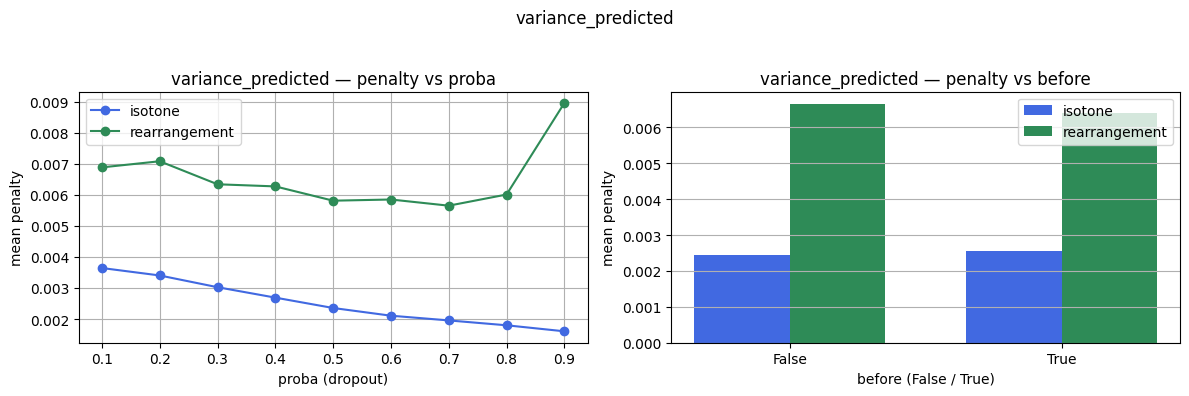

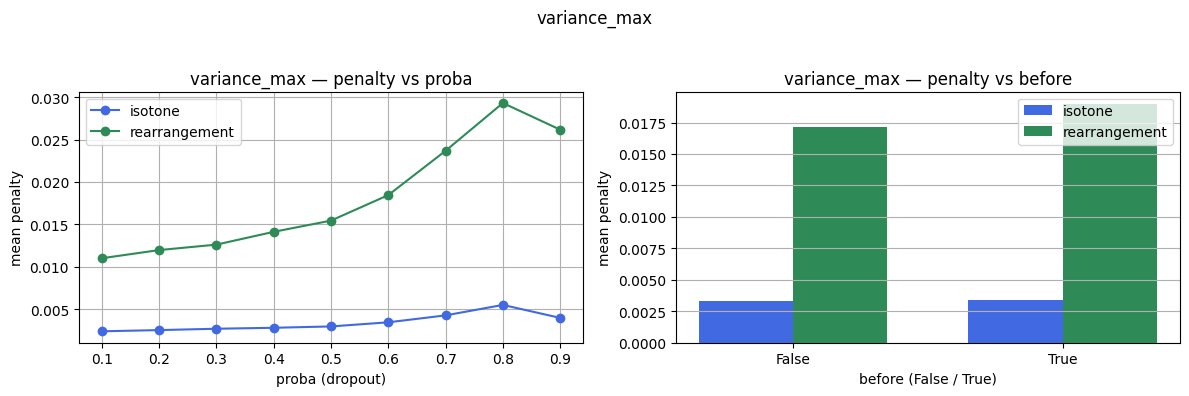

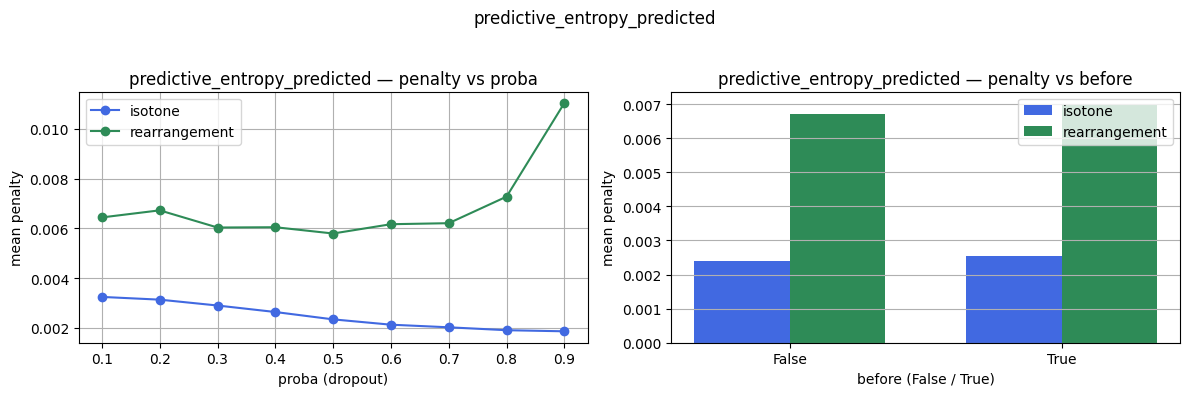

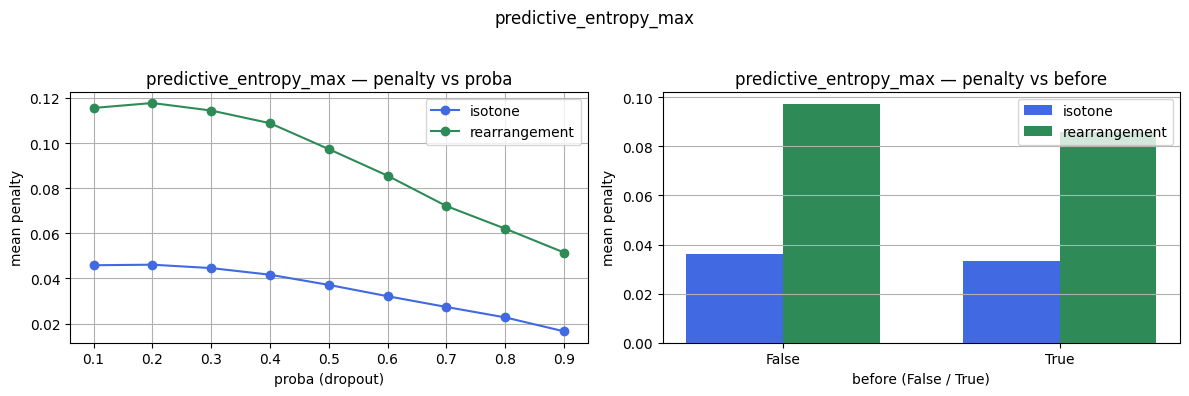

In [11]:
# construit un DataFrame "plat" avec colonnes pour chaque metric/penalty
flat = df[["config_id","proba","before"]].copy()
for m in metrics:
    for p in penalties:
        colname = f"{m}__{p}"
        flat[colname] = df["penalties"].apply(lambda s, mm=m, pp=p: parse_penalties(s, mm, pp))

# supprime lignes sans proba
flat = flat.dropna(subset=["proba"]).reset_index(drop=True)

# groupby par proba (moyenne)
group_proba = flat.groupby("proba").mean().sort_index()

# groupby par before (moyenne)
group_before = flat.groupby("before").mean()

# Plot : pour chaque métrique, deux sous-graphes (gauche : penalty vs proba; droite : penalty vs before)
for m in metrics:
    iso_col = f"{m}__penalty_isotone"
    rearr_col = f"{m}__penalty_rearrangement"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

    # gauche : moyenne par proba
    ax1.plot(group_proba.index.values, group_proba[iso_col].values, marker='o', label='isotone', color='royalblue')
    ax1.plot(group_proba.index.values, group_proba[rearr_col].values, marker='o', label='rearrangement', color='seagreen')
    ax1.set_xlabel("proba (dropout)")
    ax1.set_ylabel("mean penalty")
    ax1.set_title(f"{m} — penalty vs proba")
    ax1.grid(True)
    ax1.legend()

    # droite : moyenne par before (barres)
    x = np.arange(len(group_before.index))
    width = 0.35
    ax2.bar(x - width/2, group_before[iso_col].values, width, label='isotone', color='royalblue')
    ax2.bar(x + width/2, group_before[rearr_col].values, width, label='rearrangement', color='seagreen')
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(idx) for idx in group_before.index])
    ax2.set_xlabel("before (False / True)")
    ax2.set_ylabel("mean penalty")
    ax2.set_title(f"{m} — penalty vs before")
    ax2.legend()
    ax2.grid(axis='y')

    plt.suptitle(m)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Nombre de couches masquées

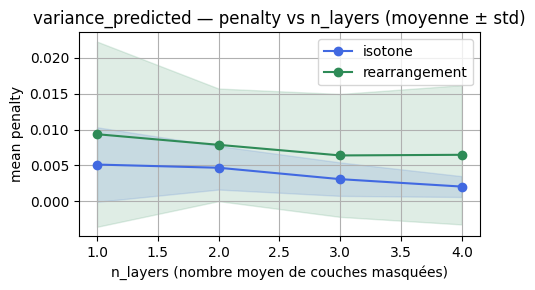

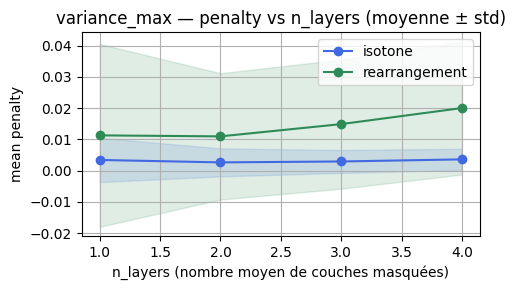

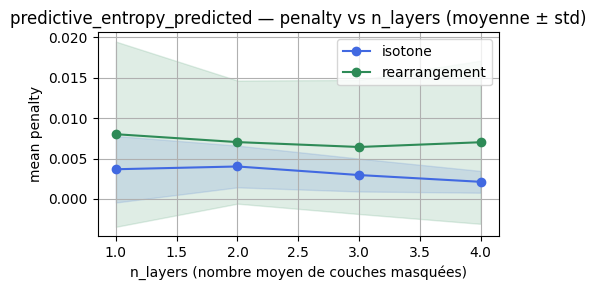

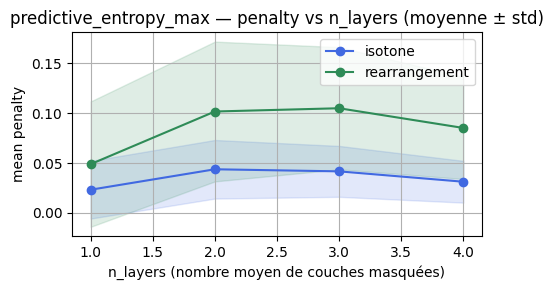

In [12]:
for m in metrics:
    for p in penalties:
        df[f"{m}__{p}"] = df["penalties"].apply(lambda s, mm=m, pp=p: parse_penalties(s, mm, pp))

flat = df[["config_id","n_layers"] + [f"{m}__{p}" for m in metrics for p in penalties]].dropna(subset=["n_layers"]).reset_index(drop=True)
metric_cols = [f"{m}__{p}" for m in metrics for p in penalties]

group_n = flat.groupby("n_layers")[metric_cols].agg(['mean','std']).sort_index()

for m in metrics:
    iso = f"{m}__penalty_isotone"
    rearr = f"{m}__penalty_rearrangement"

    x = group_n.index.values
    iso_mean = group_n[(iso,'mean')].values
    iso_std  = group_n[(iso,'std')].values
    rearr_mean = group_n[(rearr,'mean')].values
    rearr_std  = group_n[(rearr,'std')].values

    fig, ax = plt.subplots(figsize=(5,3))
    ax.plot(x, iso_mean, marker='o', label='isotone', color='royalblue')
    ax.fill_between(x, iso_mean - iso_std, iso_mean + iso_std, color='royalblue', alpha=0.15)
    ax.plot(x, rearr_mean, marker='o', label='rearrangement', color='seagreen')
    ax.fill_between(x, rearr_mean - rearr_std, rearr_mean + rearr_std, color='seagreen', alpha=0.15)

    ax.set_xlabel("n_layers (nombre moyen de couches masquées)")
    ax.set_ylabel("mean penalty")
    ax.set_title(f"{m} — penalty vs n_layers (moyenne ± std)")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close(fig)

Proba de la couche la plus profonde

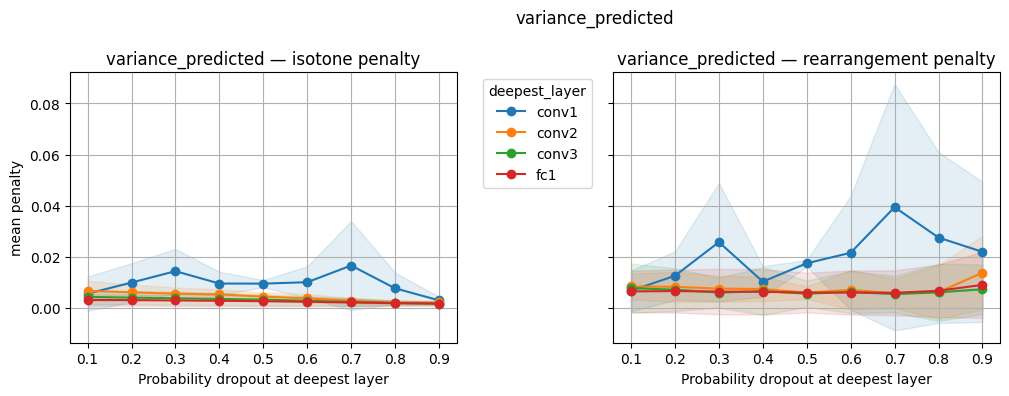

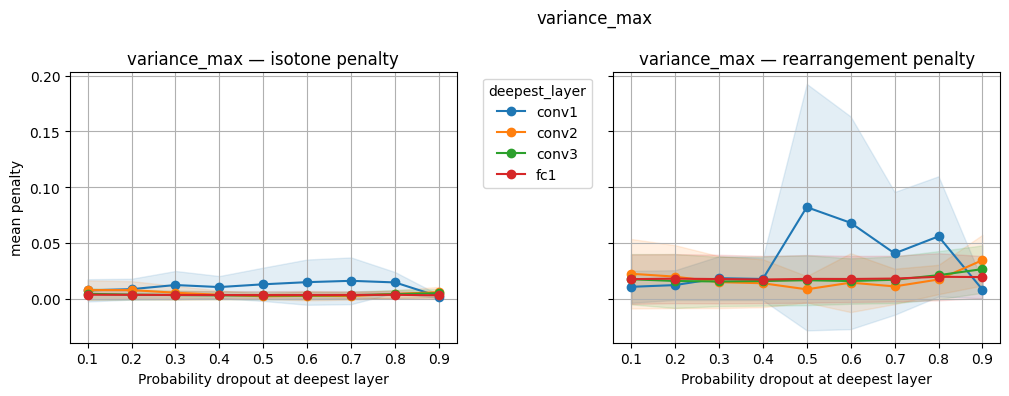

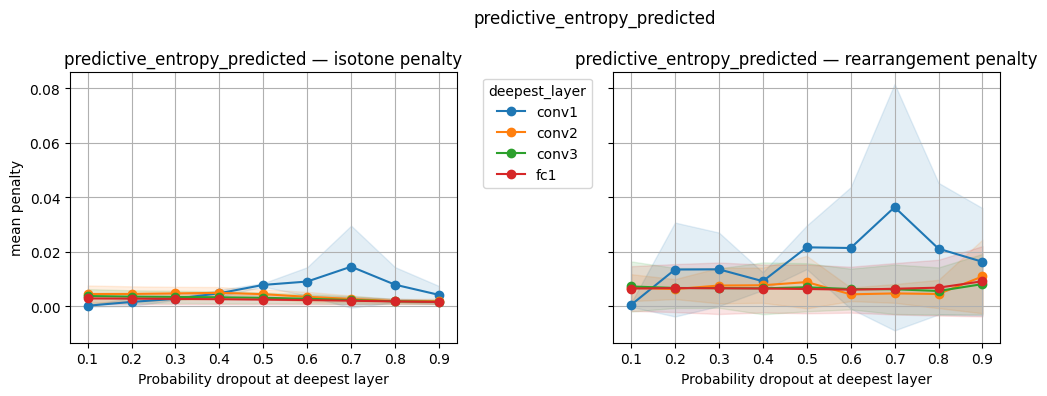

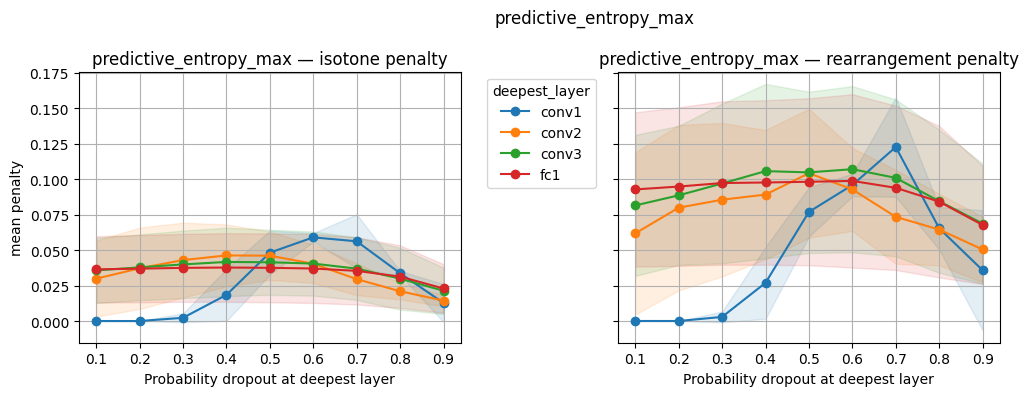

In [13]:
layer_order = ["conv1", "conv2", "conv3", "fc1"]
def deepest_layer_info(d):
    if not d:
        return (None, np.nan)
    idx_name_pairs = [(layer_order.index(k), k) for k in d.keys() if k in layer_order]
    if not idx_name_pairs:
        k = max(d.items(), key=lambda x: x[0])[0]
        return (k, float(d[k]))
    deepest_idx, deepest_name = max(idx_name_pairs, key=lambda x: x[0])
    return (deepest_name, float(d[deepest_name]))

df[["deepest_layer","deepest_proba"]] = df["dico_parsed"].apply(lambda d: pd.Series(deepest_layer_info(d)))


def parse_penalty_value(s, metric, penalty):
    try:
        dd = ast.literal_eval(s)
        return float(dd[metric][penalty])
    except Exception:
        return np.nan

# for m in metrics:
#     for p in penalties:
#         df[f"{m}__{p}"] = df["penalties"].apply(lambda s, mm=m, pp=p: parse_penalty_value(s, mm, pp))

flat = df[["config_id","deepest_layer","deepest_proba"] + [f"{m}__{p}" for m in metrics for p in penalties]].dropna(subset=["deepest_layer"]).reset_index(drop=True)
metric_cols = [f"{m}__{p}" for m in metrics for p in penalties]

unique_layers = sorted(flat["deepest_layer"].dropna().unique())
colors = {name: plt.cm.tab10(i % 10) for i, name in enumerate(unique_layers)}

for m in metrics:
    iso = f"{m}__penalty_isotone"
    rearr = f"{m}__penalty_rearrangement"

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4), sharey=True)

    for name in unique_layers:
        sub = flat[flat["deepest_layer"] == name].dropna(subset=["deepest_proba"])
        if sub.empty:
            continue
        grp = sub.groupby("deepest_proba")[[iso,rearr]].agg(['mean','std']).sort_index()
        x = grp.index.values
        iso_mean = grp[(iso,'mean')].values
        iso_std  = grp[(iso,'std')].values
        rearr_mean = grp[(rearr,'mean')].values
        rearr_std  = grp[(rearr,'std')].values

        ax1.plot(x, iso_mean, marker='o', label=str(name), color=colors[name])
        ax1.fill_between(x, iso_mean - iso_std, iso_mean + iso_std, color=colors[name], alpha=0.12)
        ax2.plot(x, rearr_mean, marker='o', label=str(name), color=colors[name])
        ax2.fill_between(x, rearr_mean - rearr_std, rearr_mean + rearr_std, color=colors[name], alpha=0.12)

    ax1.set_xlabel("Probability dropout at deepest layer")
    ax1.set_ylabel("mean penalty")
    ax1.set_title(f"{m} — isotone penalty")
    ax1.grid(True)
    ax1.legend(title="deepest_layer", bbox_to_anchor=(1.05,1), loc='upper left')

    ax2.set_xlabel("Probability dropout at deepest layer")
    ax2.set_title(f"{m} — rearrangement penalty")
    ax2.grid(True)

    plt.suptitle(m)
    plt.tight_layout(rect=[0,0,0.85,1])
    plt.show()
    plt.close(fig)

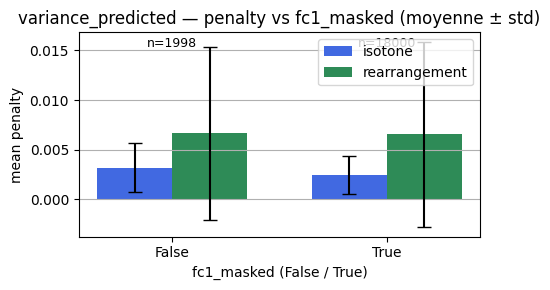

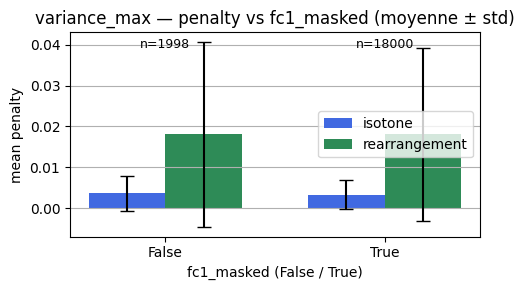

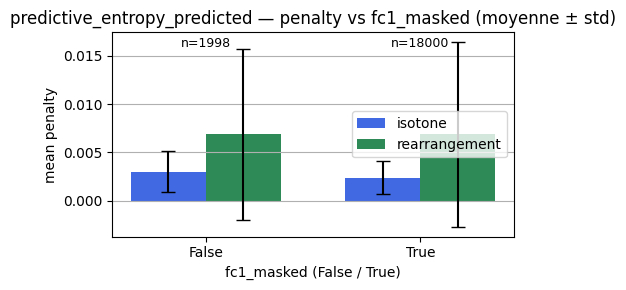

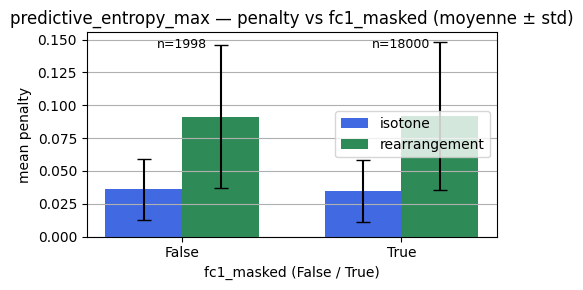

In [14]:
# comparaison mean ± std des pénalités selon si fc1 est masquée ou non

def fc1_masked_from_dico(s):
    try:
        d = ast.literal_eval(s)
        if isinstance(d, dict):
            return 'fc1' in d
    except Exception:
        pass
    return False

df["fc1_masked"] = df["dico_layers"].apply(fc1_masked_from_dico)


# DataFrame plat avec colonnes metrics__penalty
flat = df[["config_id","fc1_masked"]].copy()
for m in metrics:
    for p in penalties:
        col = f"{m}__{p}"
        flat[col] = df["penalties"].apply(lambda s, mm=m, pp=p: parse_penalties(s, mm, pp))

# groupby par fc1_masked
metric_cols = [f"{m}__{p}" for m in metrics for p in penalties]
group_fc1 = flat.groupby("fc1_masked")[metric_cols].agg(['mean','std']).sort_index()

# counts par groupe
counts = flat.groupby("fc1_masked").size().reindex(group_fc1.index, fill_value=0)

# tracé : un graphique par métrique, barres mean ± std (x = fc1_masked False/True)
for m in metrics:
    iso = f"{m}__penalty_isotone"
    rearr = f"{m}__penalty_rearrangement"

    x = np.arange(len(group_fc1.index))  # positions (False, True) ou selon present
    iso_mean = group_fc1[(iso,'mean')].values
    iso_std  = group_fc1[(iso,'std')].values
    rearr_mean = group_fc1[(rearr,'mean')].values
    rearr_std  = group_fc1[(rearr,'std')].values

    fig, ax = plt.subplots(figsize=(5,3))
    width = 0.35
    ax.bar(x - width/2, iso_mean, width, yerr=iso_std, label='isotone', color='royalblue', capsize=5)
    ax.bar(x + width/2, rearr_mean, width, yerr=rearr_std, label='rearrangement', color='seagreen', capsize=5)

    # labels x as False/True (fc1 masked)
    xticks = [str(idx) for idx in group_fc1.index]
    ax.set_xticks(x)
    ax.set_xticklabels(xticks)
    ax.set_xlabel("fc1_masked (False / True)")
    ax.set_ylabel("mean penalty")
    ax.set_title(f"{m} — penalty vs fc1_masked (moyenne ± std)")
    ax.grid(axis='y')
    ax.legend()

    # annoter le nombre de configs au-dessus des paires de barres
    for xi, cnt in zip(x, counts.values):
        ax.text(xi, ax.get_ylim()[1]*0.97, f"n={cnt}", ha='center', va='top', fontsize=9)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

Skewness

In [27]:
from scipy.stats import skew

layer_order = ["conv1", "conv2", "conv3", "fc1"]
layer_index = {name: i+1 for i, name in enumerate(layer_order)}

def probs_as_distribution(d):
    """
    Transforme un dict de proba en un vecteur de longueur 4
    normalisé en distribution (somme=1).
    """
    vec = np.array([float(d.get(layer, 0.0)) for layer in layer_order], dtype=float)
    s = vec.sum()
    if s <= 0:
        return vec  # tout zéro => distribution plate ? mais ici on laisse zéro
    return vec / s

def compute_skewness(d):
    """
    Calcule la skewness sur les indices pondérés par les probas normalisées.
    """
    probs = probs_as_distribution(d)
    indices = np.array([layer_index[l] for l in layer_order], dtype=float)

    # skewness pondérée (moment d'ordre 3)
    mean = np.sum(indices * probs)
    var = np.sum(probs * (indices - mean)**2)
    std = np.sqrt(var)

    if std == 0:
        return 0.0
    
    skew_val = np.sum(probs * ((indices - mean) / std)**3)
    return float(skew_val)

# colonne skewness
df["skewness"] = df["dico_parsed"].apply(compute_skewness)

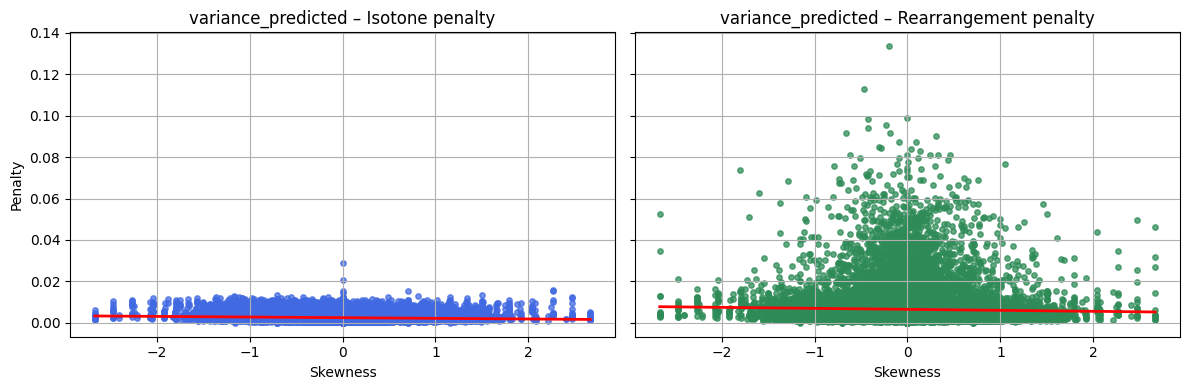

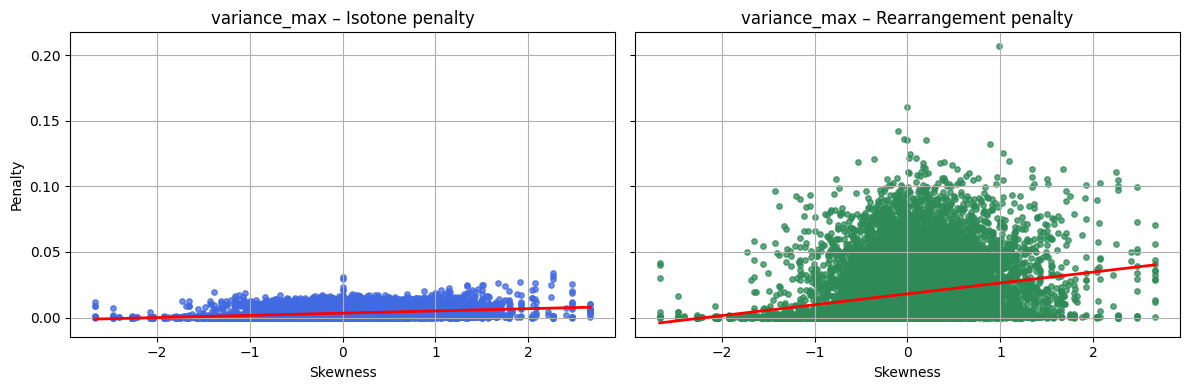

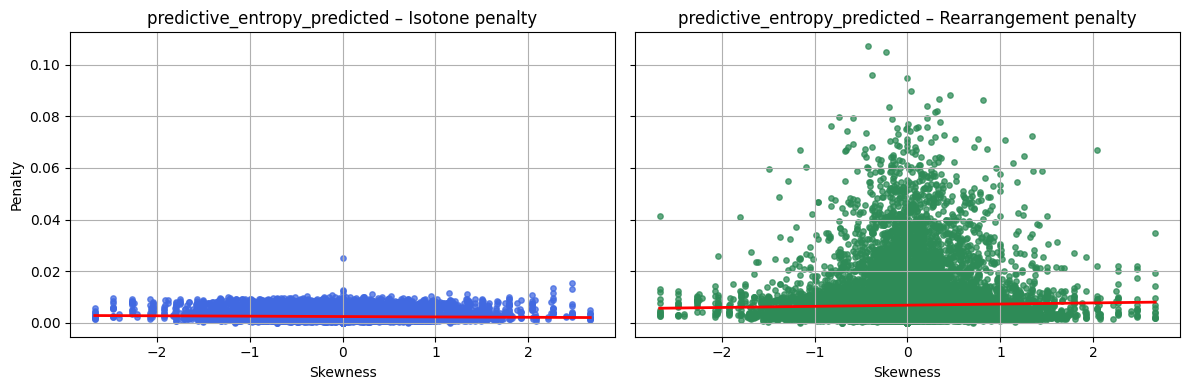

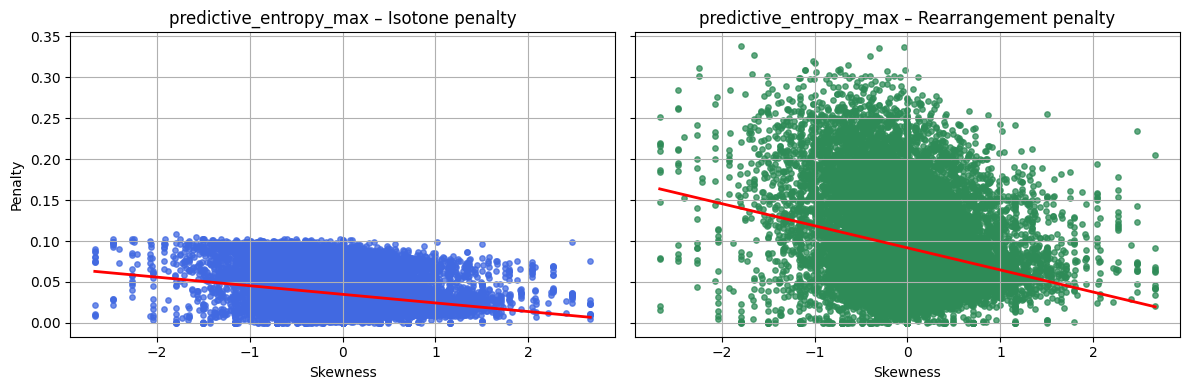

In [ ]:
from sklearn.linear_model import LinearRegression

# Nouveau DataFrame pour skewness + pénalités
flat_skew = df[["skewness"]].copy()
for m in metrics:
    for p in penalties:
        flat_skew[f"{m}__{p}"] = df[f"{m}__{p}"]

flat_skew = flat_skew.dropna()

# def add_regression(ax, x, y, color):
#         X = x.values.reshape(-1, 1)
#         model = LinearRegression().fit(X, y.values)
#         x_line = np.linspace(x.min(), x.max(), 200).reshape(-1,1)
#         y_line = model.predict(x_line)
#         ax.plot(x_line, y_line, color=color, linewidth=2)
        
for m in metrics:
    iso_col = f"{m}__penalty_isotone"
    rearr_col = f"{m}__penalty_rearrangement"

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    ax = axs[0]
    ax.scatter(flat_skew["skewness"], flat_skew[iso_col],
               color="royalblue", alpha=0.75, s=15, label="Isotone")

    # add_regression(ax, flat_skew["skewness"], flat_skew[iso_col], "red")

    ax.set_title(f"{m} – Isotone penalty", fontsize=12)
    ax.set_xlabel("Skewness")
    ax.set_ylabel("Penalty")
    ax.grid(True)

    ax = axs[1]
    ax.scatter(flat_skew["skewness"], flat_skew[rearr_col],
               color="seagreen", alpha=0.75, s=15, label="Rearrangement")

    # add_regression(ax, flat_skew["skewness"], flat_skew[rearr_col], "red")

    ax.set_title(f"{m} – Rearrangement penalty", fontsize=12)
    ax.set_xlabel("Skewness")
    ax.grid(True)

    plt.tight_layout()
    plt.show()


# rajouter skewness (moment d'ordre 3)
ça je trace pas, c'est ce qu'on veut
- en abscisse : couche masquée (1 pour conv1 etc)
- en ordonnée : distribution des probas de masquage pour l'ensemble des couches
il faut normaliser pour que ça soit une distribution de probas et avoir une densité
ex : si j'ai 3 bâtons il faut que ce soit 1/3 1/3 1/3, si j'ai 0,9 0,9 0,9 pour probas de masquage pour 3 couches
il faut avoir une somme des bâtonnets qui vaut 1

est-ce que c'est plus intéressant de masquer tard (fc1) ou tôt (conv1) = est-ce que la proba de masquage est plus élevée à la fin ou au début ou non
on peut calculer la skewness de cette distribution pour voir si elle est asymétrique

Ce que je trace (comme le tout premier graphique) : 
- en abscisse la skewness
- en ordonnée la pénalité

# Kurtosis (moment d'ordre 4) 
désigne s'il y a des pics ou non, se rajoute en une ligne après la skewness
tracer aussi

visualisation des paramètres : 
- groupby : proba, et faire la moyenne de penalty ; mode = moyenne(mean)
- en ordonnée : var_pred et abscisse : proba ou before/after 

essayer de représenter selon les couches : 
- essayer de mettre en abscisse la moyenne par nombre de couches
- essayer de mettre en abscisse la proba de la couche la plus profonde (et préciser laquelle)

aussi :
- en abscisse mettre si masquage de fc1 ou non

aussi : 
- par tranche selon la variance des probas (quantiles), plotter la moyenne des probas de masquage comme config 